## Problem Statement

* Analyze the food delivery dataset using Exploratory Data Analysis (EDA).
* Understand customer ordering behavior and purchasing patterns.
* Identify the most popular cities, restaurant categories, and payment methods.
* Analyze order value, delivery fee, discounts, customer ratings, and delivery performance.
* Clean the dataset by handling missing values, duplicate records, inconsistent values, skewness, and outliers.
* Visualize the data using Python libraries such as **Pandas, NumPy, Matplotlib, and Seaborn**.
* Perform statistical and graphical analysis to identify trends and patterns.
* Generate meaningful business insights to support better decision-making and improve food delivery services.
* Provide recommendations to enhance customer satisfaction and operational efficiency.


In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [79]:
df = pd.read_csv('food_delivery_synthetic_dataset.csv')

In [80]:
df.head()

,Order_ID,Customer_ID,Restaurant_ID,Delivery_Partner_ID,Order_Date,Order_Time,City,Area,Restaurant_Name,Restaurant_Category,...,Distance_km,Weather,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status
0,ORD0309353,CUST118495,NaN,DP02115,2023-11-05,21:03:05,Mumbai,NaN,Fresh House,Street Food,...,11.77,Heatwave,Medium,67.0,231.35,5.20,UPI,NaN,NaN,Delivered
1,ORD0124468,CUST021794,REST05389,DP02174,2023-10-09,21:01,Nagpur,Sadar,Annapurna Spot,Juices,...,2.96,NaN,NaN,29.0,116.82,14.35,UPI,34.76,4.0,Delivered
2,ORD0012315,CUST097889,REST06138,DP00225,2023-11-27,20:59:56,Hyderabad,NaN,Little Diner,Juices,...,2.82,Heatwave,Medium,40.0,80.00,1.86,Credit Card,26.24,3.0,Returned
3,ORD0684514,CUST036679,REST03010,DP00510,2024-10-05,06:07 PM,Bengaluru,BTM Layout,Sizzling Adda,North Indian,...,0.98,Rainy,Medium,22.0,511.85,29.07,UPI,42.03,5.0,Delivered
4,ORD0127193,CUST017422,REST04334,DP03177,2023-07-20,12:15:17,Kolkata,NaN,Fresh Tadka,Street Food,...,5.31,NaN,NaN,58.0,142.33,199.83,Debit Card,64.95,3.0,Delivered


In [81]:
df.tail()

,Order_ID,Customer_ID,Restaurant_ID,Delivery_Partner_ID,Order_Date,Order_Time,City,Area,Restaurant_Name,Restaurant_Category,...,Distance_km,Weather,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status
741595,ORD0239306,CUST104573,REST01622,DP02677,05/15/2024,16:25,delhi,Karol Bagh,Spice Table,Biryani,...,3.71,Heatwave,NaN,31.0,138.00,5.95,Net Banking,44.73,3.0,Refunded
741596,ORD0691369,CUST059280,REST06203,DP01407,2023-01-23,14:02,Pune,Wakad,Green Rasoi,NaN,...,NaN,NaN,Medium,39.0,NaN,31.78,Wallet,47.08,5.0,Delivered
741597,ORD0177338,CUST025445,REST03147,DP02251,03-05-2023,20:37,Chennai,Velachery,Bengal Point,Cafe,...,NaN,Heatwave,Medium,50.0,231.70,16.69,NaN,25.37,3.0,Delivered
741598,ORD0547876,CUST010861,REST05354,NaN,05/02/2024,18:49:03,Nagpur,Civil Lines,Annapurna Villa137,Rolls,...,5.83,Cloudy,high,51.0,393.12,0.89,Cash,66.53,4.0,Delivered
741599,ORD0684674,NaN,REST03737,DP03144,19/11/2024,08:55 PM,Nagpur,Wardha Road,The Adda,Momos,...,2.11,Fog,Very High,47.0,106.36,27.09,Wallet,51.30,4.0,Delivered


## Performing EDA(Exploratory Data Analysis)

## 1) Understanding the Dataset

In [82]:
## Checking numbers of rows and columns
df.shape

(741600, 22)

In [83]:
## Checking columns names from dataset
df.columns

Index(['Order_ID', 'Customer_ID', 'Restaurant_ID', 'Delivery_Partner_ID',
       'Order_Date', 'Order_Time', 'City', 'Area', 'Restaurant_Name',
       'Restaurant_Category', 'Customer_Age', 'Customer_Gender', 'Distance_km',
       'Weather', 'Traffic_Level', 'Delivery_Time_Minutes', 'Order_Value',
       'Discount', 'Payment_Method', 'Delivery_Fee', 'Customer_Rating',
       'Order_Status'],
      dtype='object')

In [84]:
## Checking the Datatypes of Columns
df.dtypes

Order_ID                  object
Customer_ID               object
Restaurant_ID             object
Delivery_Partner_ID       object
Order_Date                object
Order_Time                object
City                      object
Area                      object
Restaurant_Name           object
Restaurant_Category       object
Customer_Age             float64
Customer_Gender           object
Distance_km              float64
Weather                   object
Traffic_Level             object
Delivery_Time_Minutes    float64
Order_Value              float64
Discount                 float64
Payment_Method            object
Delivery_Fee             float64
Customer_Rating          float64
Order_Status              object
dtype: object

In [85]:
df['Order_Date'].unique()

array(['2023-11-05', '2023-10-09', '2023-11-27', ..., '2023.09.05',
       '2024.07.01', '2024.11.18'], shape=(4092,), dtype=object)

In [87]:
## Changing the Order Date Data type from  object to date_Time
# Replace '.' with '-'
df['Order_Date'] = df['Order_Date'].str.replace('.', '-', regex=False)

# Convert to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Check datatype
print(df['Order_Date'].dtype)

datetime64[ns]


In [95]:
df['Year'] = pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
).dt.year.astype('Int32')

In [101]:
df['Month']=pd.to_datetime(
    df['Order_Date'],
    errors='coerce'
).dt.month_name()

In [102]:
df.head()

,Order_ID,Customer_ID,Restaurant_ID,Delivery_Partner_ID,Order_Date,Order_Time,City,Area,Restaurant_Name,Restaurant_Category,...,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status,Year,Month
0,ORD0309353,CUST118495,NaN,DP02115,2023-11-05,21:03:05,Mumbai,NaN,Fresh House,Street Food,...,Medium,67.0,231.35,5.20,UPI,NaN,NaN,Delivered,2023,November
1,ORD0124468,CUST021794,REST05389,DP02174,2023-10-09,21:01,Nagpur,Sadar,Annapurna Spot,Juices,...,NaN,29.0,116.82,14.35,UPI,34.76,4.0,Delivered,2023,October
2,ORD0012315,CUST097889,REST06138,DP00225,2023-11-27,20:59:56,Hyderabad,NaN,Little Diner,Juices,...,Medium,40.0,80.00,1.86,Credit Card,26.24,3.0,Returned,2023,November
3,ORD0684514,CUST036679,REST03010,DP00510,2024-10-05,06:07 PM,Bengaluru,BTM Layout,Sizzling Adda,North Indian,...,Medium,22.0,511.85,29.07,UPI,42.03,5.0,Delivered,2024,October
4,ORD0127193,CUST017422,REST04334,DP03177,2023-07-20,12:15:17,Kolkata,NaN,Fresh Tadka,Street Food,...,NaN,58.0,142.33,199.83,Debit Card,64.95,3.0,Delivered,2023,July


## 2) Data Inspection

In [8]:
df.info()   ## Summary of Dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 741600 entries, 0 to 741599
Data columns (total 22 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Order_ID               741600 non-null  object 
 1   Customer_ID            644672 non-null  object 
 2   Restaurant_ID          645117 non-null  object 
 3   Delivery_Partner_ID    629983 non-null  object 
 4   Order_Date             741600 non-null  object 
 5   Order_Time             741600 non-null  object 
 6   City                   726942 non-null  object 
 7   Area                   593292 non-null  object 
 8   Restaurant_Name        719459 non-null  object 
 9   Restaurant_Category    667634 non-null  object 
 10  Customer_Age           661159 non-null  float64
 11  Customer_Gender        697203 non-null  object 
 12  Distance_km            645514 non-null  float64
 13  Weather                563289 non-null  object 
 14  Traffic_Level          623154 non-nu

In [9]:
df.describe()  ## Statistical info of data

,Customer_Age,Distance_km,Delivery_Time_Minutes,Order_Value,Discount,Delivery_Fee,Customer_Rating
count,661159.000000,645514.000000,704485.000000,704883.000000,741600.000000,668942.000000,581278.000000
mean,29.684796,4.468730,51.847279,278.478361,32.386390,55.816407,3.839512
std,9.570496,3.570357,22.026296,570.214518,84.735416,40.095367,0.733034
min,10.000000,0.000000,0.000000,0.000000,-99.990000,-60.000000,1.000000
25%,23.000000,2.090000,38.000000,128.590000,9.520000,39.320000,3.000000
50%,29.000000,3.680000,50.000000,203.310000,19.980000,51.540000,4.000000
75%,34.000000,5.920000,63.000000,317.530000,39.250000,66.780000,4.000000
max,98.000000,44.990000,299.000000,14997.720000,18778.110000,899.380000,5.000000


In [10]:
## Checking The unique values From all Categorical Column

In [11]:
categorical_columns = df.select_dtypes(include='object').columns   ## Combining all Categorical Columns

In [12]:
numerical_column = df.select_dtypes(exclude='object').columns   ## Combining all Numerical Columns

In [13]:
for col in categorical_columns:
    print(f"Column: {col}")
    print(df[col].unique())
    print('****************************')

Column: Order_ID
['ORD0309353' 'ORD0124468' 'ORD0012315' ... 'ORD0177338' 'ORD0547876'
 'ORD0684674']
****************************
Column: Customer_ID
['CUST118495' 'CUST021794' 'CUST097889' ... 'CUST067178' 'CUST107127'
 'CUST025970']
****************************
Column: Restaurant_ID
[nan 'REST05389' 'REST06138' ... 'REST04134' 'REST04931' 'REST04038']
****************************
Column: Delivery_Partner_ID
['DP02115' 'DP02174' 'DP00225' ... 'DP01532' 'DP01760' 'DP01873']
****************************
Column: Order_Date
['2023-11-05' '2023-10-09' '2023-11-27' ... '2023.09.05' '2024.07.01'
 '2024.11.18']
****************************
Column: Order_Time
['21:03:05' '21:01' '20:59:56' ... '09:31:50 PM' '05:53:58 PM'
 '01:48:54 AM']
****************************
Column: City
['Mumbai' 'Nagpur' 'Hyderabad' 'Bengaluru' 'Kolkata' nan 'Chennai'
 'Ahmedabad' 'Luckhnow' 'Pune' 'Indore' 'Delhi' 'Surat' 'NAGPUR' 'Jaipur'
 'New Delhi' 'Bangalore' 'Bombay' 'mumbai' 'ahmedabad' 'Mumbai ' 'Nagpurr'
 '

In [14]:
df[df.duplicated()]

,Order_ID,Customer_ID,Restaurant_ID,Delivery_Partner_ID,Order_Date,Order_Time,City,Area,Restaurant_Name,Restaurant_Category,...,Distance_km,Weather,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status
7844,ORD0416556,CUST042422,REST02307,DP04138,01 Dec 2023,14:28,Delhi,Saket,Desi Rasoi,North Indian,...,5.77,Sunny,Medium,53.0,80.00,2.51,Cash,820.93,NaN,Delivered
9024,ORD0704897,CUST004336,REST02977,DP02100,2024.12.16,07:07:59,Indore,Sudama Nagar,Annapurna Treat,Biryani,...,1.45,Fog,Medium,34.0,343.83,0.27,UPI,34.91,3.0,Delivered
9139,ORD0294441,CUST085481,REST00743,DP00373,19-12-2024,13:12:13,Bengaluru,NaN,Bengal Corner,Street Food,...,3.26,Fog,NaN,39.0,80.00,11.03,UPI,48.69,3.0,Delivered
9321,ORD0307048,NaN,REST06115,DP00119,2023-05-08,16:40,Bombay,Andheri,Tasty House,South Indian,...,3.57,Heatwave,Low,25.0,456.83,50.66,UPI,44.10,4.0,Refunded
10438,ORD0656898,NaN,REST06126,DP01905,23/09/2024,08:47 PM,Hyderabad,Banjara Hills,Urban Adda,Biryani,...,0.72,Cloudy,Medium,41.0,248.22,21.64,Debit Card,34.85,4.0,Delivered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
741501,ORD0363185,CUST014330,REST04268,DP00834,20-11-2023,07:11:09 AM,Bengaluru,Koramangala,Pure Bowl,NaN,...,2.15,Sunny,High,29.0,169.77,10.46,NaN,37.25,4.0,Delivered
741527,ORD0035166,CUST098183,REST06132,DP03927,26/06/2023,22:44:40,Bengaluru,Whitefield,Shree Cafe,Healthy Food,...,1.93,Cloudy,Very High,38.0,321.22,4.80,Cash,43.34,4.0,Delivered
741528,ORD0207843,CUST095172,REST03287,DP03353,2023-06-18,19:00:13,Jaipur city,Jagatpura,Southern Cafe,Chinese,...,4.38,Heatwave,Medium,33.0,151.97,5.79,UPI,46.80,5.0,Delivered
741536,ORD0586363,CUST000383,REST06477,NaN,2023-03-09,01:27 PM,Hyderabad,NaN,Urban Diner,Street Food,...,11.57,Sunny,Very High,76.0,80.00,7.87,UPI,99.28,4.0,Delivered


In [15]:
 ## Checking and Removing Duplicate Rows

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.shape  ## 21600 Duplicate Rows are deleted

(720000, 22)

In [18]:
## Checking Missing values

In [19]:
df.isnull().sum()

Order_ID                      0
Customer_ID               94151
Restaurant_ID             93655
Delivery_Partner_ID      108300
Order_Date                    0
Order_Time                    0
City                      14237
Area                     143962
Restaurant_Name           21508
Restaurant_Category       71833
Customer_Age              78059
Customer_Gender           43045
Distance_km               93313
Weather                  173212
Traffic_Level            115086
Delivery_Time_Minutes     36049
Order_Value               35628
Discount                      0
Payment_Method           143771
Delivery_Fee              70440
Customer_Rating          155590
Order_Status                  0
dtype: int64

## 3) Data Cleaning

In [20]:
## Removing Unwanted Columns

In [21]:
df.drop(columns=[
    'Order_ID',
    'Customer_ID',
    'Restaurant_ID',
    'Delivery_Partner_ID'
], inplace=True)

In [22]:
df.drop(columns='Order_Time', inplace=True)

In [23]:
df.head()

,Order_Date,City,Area,Restaurant_Name,Restaurant_Category,Customer_Age,Customer_Gender,Distance_km,Weather,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status
0,2023-11-05,Mumbai,NaN,Fresh House,Street Food,23.0,Female,11.77,Heatwave,Medium,67.0,231.35,5.20,UPI,NaN,NaN,Delivered
1,2023-10-09,Nagpur,Sadar,Annapurna Spot,Juices,38.0,Female,2.96,NaN,NaN,29.0,116.82,14.35,UPI,34.76,4.0,Delivered
2,2023-11-27,Hyderabad,NaN,Little Diner,Juices,NaN,Female,2.82,Heatwave,Medium,40.0,80.00,1.86,Credit Card,26.24,3.0,Returned
3,2024-10-05,Bengaluru,BTM Layout,Sizzling Adda,North Indian,40.0,NaN,0.98,Rainy,Medium,22.0,511.85,29.07,UPI,42.03,5.0,Delivered
4,2023-07-20,Kolkata,NaN,Fresh Tadka,Street Food,42.0,Female,5.31,NaN,NaN,58.0,142.33,199.83,Debit Card,64.95,3.0,Delivered


In [24]:
## Handling Missing Values

In [25]:
df.isnull().sum()

Order_Date                    0
City                      14237
Area                     143962
Restaurant_Name           21508
Restaurant_Category       71833
Customer_Age              78059
Customer_Gender           43045
Distance_km               93313
Weather                  173212
Traffic_Level            115086
Delivery_Time_Minutes     36049
Order_Value               35628
Discount                      0
Payment_Method           143771
Delivery_Fee              70440
Customer_Rating          155590
Order_Status                  0
dtype: int64

In [26]:
categorical_columns_1 = df.select_dtypes(include='object').columns   ## Combining all Categorical Columns after droping some columns

In [27]:
numerical_column_1 = df.select_dtypes(exclude='object').columns   ## Combining all Numerical Columns after droping some columns

In [28]:
## Handling Missing Values in Categorical Column using Mode
for col in categorical_columns_1:
    df[col] = df[col].fillna(df[col].mode()[0])

In [29]:
df.isnull().sum()

Order_Date                    0
City                          0
Area                          0
Restaurant_Name               0
Restaurant_Category           0
Customer_Age              78059
Customer_Gender               0
Distance_km               93313
Weather                       0
Traffic_Level                 0
Delivery_Time_Minutes     36049
Order_Value               35628
Discount                      0
Payment_Method                0
Delivery_Fee              70440
Customer_Rating          155590
Order_Status                  0
dtype: int64

In [30]:
## Handling Missing Values in Numerical Columns using Median
for num in numerical_column_1:
    df[num]=df[num].fillna(df[num].median())

In [31]:
df.isnull().sum()

Order_Date               0
City                     0
Area                     0
Restaurant_Name          0
Restaurant_Category      0
Customer_Age             0
Customer_Gender          0
Distance_km              0
Weather                  0
Traffic_Level            0
Delivery_Time_Minutes    0
Order_Value              0
Discount                 0
Payment_Method           0
Delivery_Fee             0
Customer_Rating          0
Order_Status             0
dtype: int64

In [32]:
df.head(3)

,Order_Date,City,Area,Restaurant_Name,Restaurant_Category,Customer_Age,Customer_Gender,Distance_km,Weather,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status
0,2023-11-05,Mumbai,Borivali,Fresh House,Street Food,23.0,Female,11.77,Heatwave,Medium,67.0,231.35,5.20,UPI,51.54,4.0,Delivered
1,2023-10-09,Nagpur,Sadar,Annapurna Spot,Juices,38.0,Female,2.96,Sunny,High,29.0,116.82,14.35,UPI,34.76,4.0,Delivered
2,2023-11-27,Hyderabad,Borivali,Little Diner,Juices,29.0,Female,2.82,Heatwave,Medium,40.0,80.00,1.86,Credit Card,26.24,3.0,Returned


In [33]:
## Changing the Order Date Data type from  object to date_Time
# Replace '.' with '-'
df['Order_Date'] = df['Order_Date'].str.replace('.', '-', regex=False)

# Convert to datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')

# Check datatype
print(df['Order_Date'].dtype)

datetime64[ns]


In [34]:
## Changing Datatypes
df.dtypes

Order_Date               datetime64[ns]
City                             object
Area                             object
Restaurant_Name                  object
Restaurant_Category              object
Customer_Age                    float64
Customer_Gender                  object
Distance_km                     float64
Weather                          object
Traffic_Level                    object
Delivery_Time_Minutes           float64
Order_Value                     float64
Discount                        float64
Payment_Method                   object
Delivery_Fee                    float64
Customer_Rating                 float64
Order_Status                     object
dtype: object

In [35]:
# Remove leading and trailing spaces
df['City'] = df['City'].str.strip()

# Convert to Title Case
df['City'] = df['City'].str.title()

# Standardize city names
city_mapping = {
    'Bombay': 'Mumbai',
    'Bangalore': 'Bengaluru',
    'Banglore': 'Bengaluru',
    'Madras': 'Chennai',
    'New Delhi': 'Delhi',
    'Jaipur City': 'Jaipur',
    'Poona': 'Pune',
    'Amdavad': 'Ahmedabad',
    'Nagpurr': 'Nagpur',
    'Indoor': 'Indore',
    'Suratt': 'Surat'
}

# Replace inconsistent names
df['City'] = df['City'].replace(city_mapping)

In [36]:
# Remove leading/trailing spaces
df['City'] = df['City'].str.strip()

# Convert to Title Case
df['City'] = df['City'].str.title()

# Standardize city names
city_mapping = {
    'Bombay': 'Mumbai',
    'Mumbaii': 'Mumbai',

    'Bangalore': 'Bengaluru',
    'Banglore': 'Bengaluru',

    'Madras': 'Chennai',

    'New Delhi': 'Delhi',
    'Dilli': 'Delhi',

    'Jaipur City': 'Jaipur',

    'Poona': 'Pune',

    'Amdavad': 'Ahmedabad',
    'Ahemdabad': 'Ahmedabad',

    'Nagpurr': 'Nagpur',

    'Indoor': 'Indore',

    'Suratt': 'Surat',

    'Hyderbad': 'Hyderabad',

    'Luckhnow': 'Lucknow',

    'Calcutta': 'Kolkata'
}

# Replace inconsistent city names
df['City'] = df['City'].replace(city_mapping)

In [37]:
print(df['Customer_Gender'].unique())

['Female' 'Male' 'Other' '  Male' 'FEMALE' 'Female   ' 'Male   ' ' Male '
 'MALE' ' Female ' 'male' 'female' '  Female' ' Other ' 'OTHER' 'other'
 '  Other' 'Other   ']


In [38]:
## Cleaning Unwannted values from gender
df['Customer_Gender'] = (
    df['Customer_Gender']
    .str.strip()
    .str.title()
    .replace({
        'Male': 'Male',
        'Female': 'Female',
        'Other': 'Other'
    })
)

In [39]:
## Remove unwanted spacec from Whether
df['Weather'] = df['Weather'].str.strip().str.title()

In [40]:
df['Weather'].unique()

array(['Heatwave', 'Sunny', 'Rainy', 'Cloudy', 'Fog', 'Storm'],
      dtype=object)

In [41]:
##Remove unwanted spaces and cleaning the Payment method
df['Payment_Method'].unique()

array(['UPI', 'Credit Card', 'Debit Card', '  UPI', 'Wallet',
       'Net Banking', 'Cash', 'credit card', 'wallet', 'Credit Card   ',
       '  Wallet', 'Cash   ', ' Credit Card ', ' UPI ', 'CASH',
       'Debit Card   ', 'DEBIT CARD', 'Upi', ' Cash ', ' Debit Card ',
       'Wallet   ', 'NET BANKING', 'CREDIT CARD', 'UPI   ',
       '  Debit Card', ' Net Banking ', 'upi', 'WALLET', ' Wallet ',
       'net banking', '  Cash', 'debit card', 'cash', 'Net Banking   ',
       '  Credit Card', '  Net Banking'], dtype=object)

In [42]:
## Cleaning Payment methods
df['Payment_Method'] = (
    df['Payment_Method']
    .astype(str)
    .str.strip()
    .str.replace(r'\s+', ' ', regex=True)
    .str.lower()
)

payment_map = {
    'upi': 'UPI',
    'wallet': 'Wallet',
    'cash': 'Cash',
    'credit card': 'Credit Card',
    'debit card': 'Debit Card',
    'net banking': 'Net Banking'
}

df['Payment_Method'] = df['Payment_Method'].replace(payment_map)

In [43]:
df['Traffic_Level'].unique()

array(['Medium   ', 'High', 'Medium', 'Low', 'medium', 'Very High', 'LOW',
       'MEDIUM', 'HIGH', 'Low   ', ' Low ', 'VERY HIGH', ' Medium ',
       '  Low', ' High ', ' Very High ', '  Very High', 'low',
       'very high', '  High', 'high', 'High   ', 'Very High   ',
       '  Medium'], dtype=object)

In [44]:
## Remove unwanted spaces and cleaning the traffic Level
df['Traffic_Level'] = df['Traffic_Level'].str.strip().str.title()

In [45]:
df['Order_Date'].dtype

dtype('<M8[ns]')

## Outlier Detection 

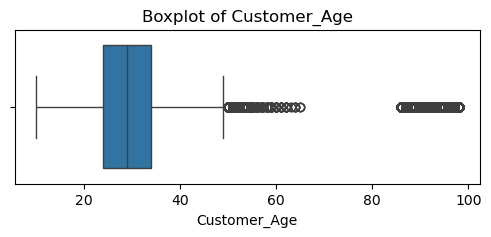

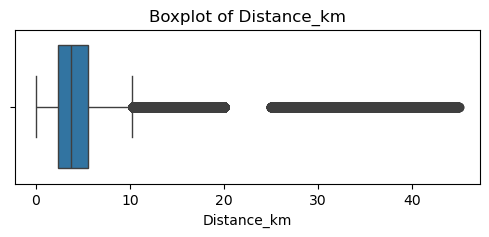

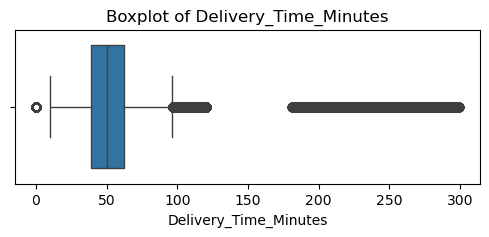

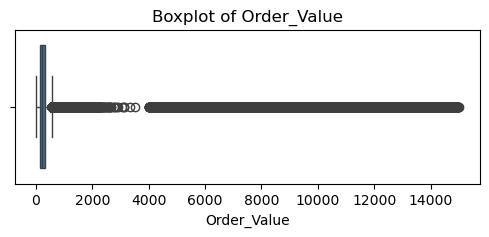

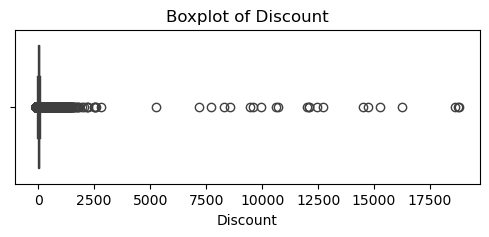

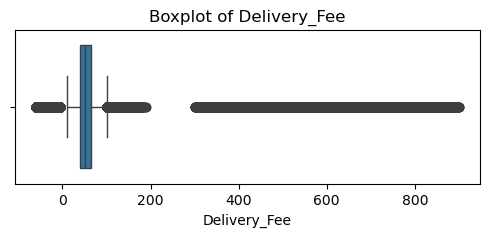

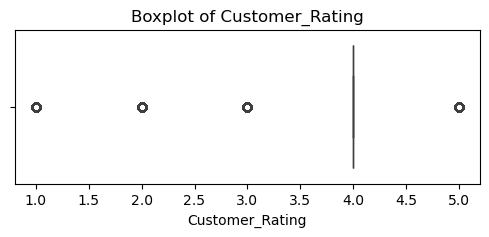

In [46]:
for col in numerical_column_1:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

In [47]:
for col in numerical_column_1:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower_limit) & (df[col] <= upper_limit)]

In [48]:
# List of numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Cap outliers using IQR
for col in numerical_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Cap the outliers
    df[col] = df[col].clip(lower=lower_limit, upper=upper_limit)

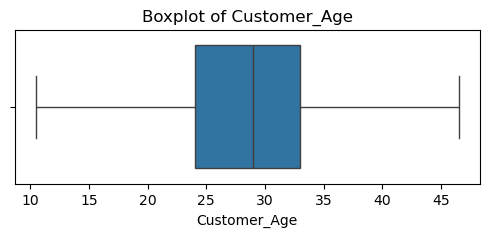

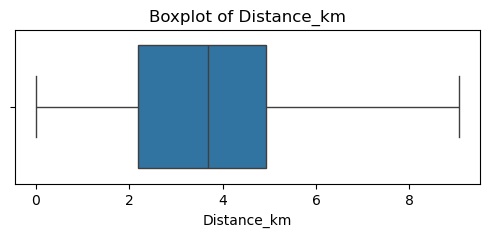

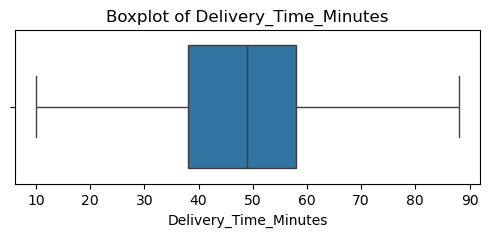

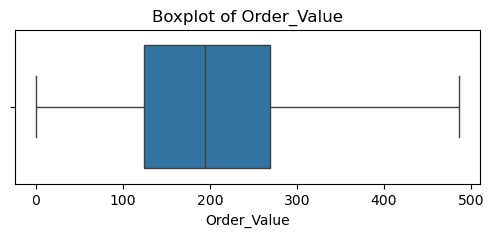

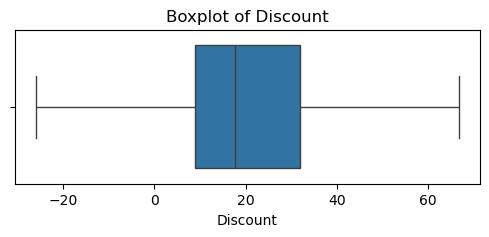

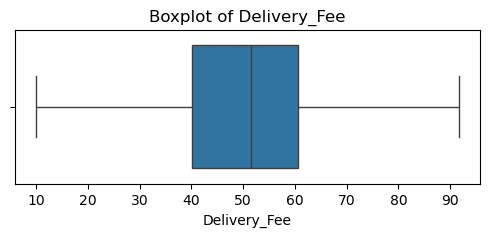

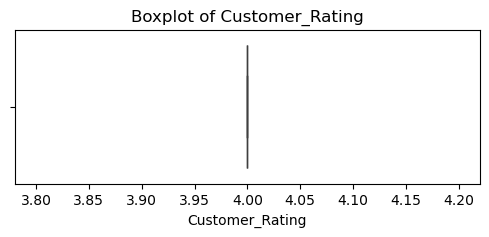

In [49]:
for col in numerical_column_1:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

## Analysis

## Top 10 Cities by Orders

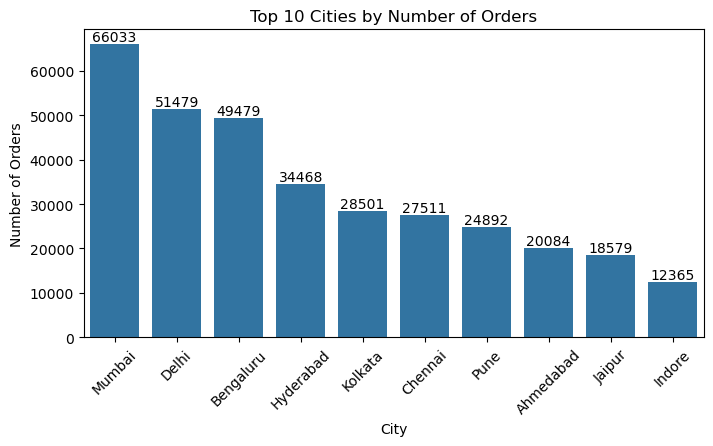

In [50]:
city = (
    df.groupby('City')
      .size()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(8,4))

ax = sns.barplot(
    x=city.index,
    y=city.values
)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("City")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.show()

##  top 10 restaurant categories

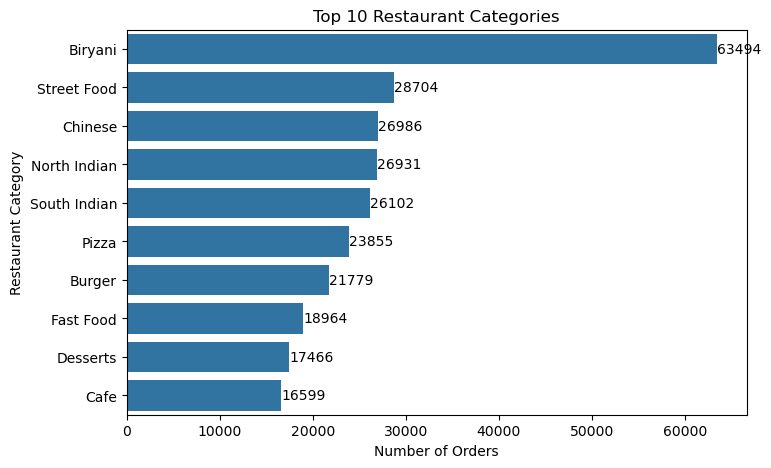

In [51]:
category = df['Restaurant_Category'].value_counts().head(10)

plt.figure(figsize=(8,5))

ax = sns.barplot(x=category.values, y=category.index)

ax.bar_label(ax.containers[0])

plt.title("Top 10 Restaurant Categories")
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Category")

plt.show()

## Orders by Payment Method

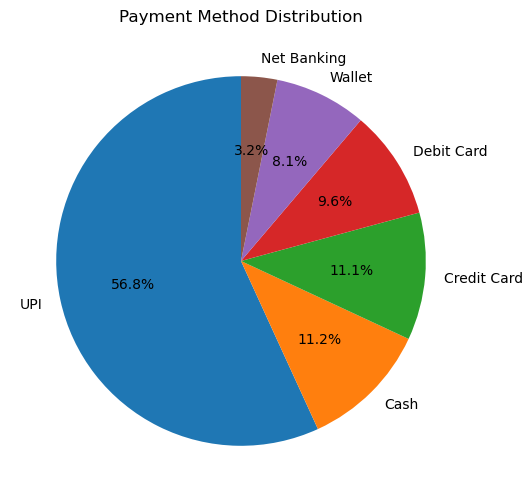

In [52]:
payment = df['Payment_Method'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(payment.values,
        labels=payment.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Payment Method Distribution")

plt.show()

## Order Status Distribution

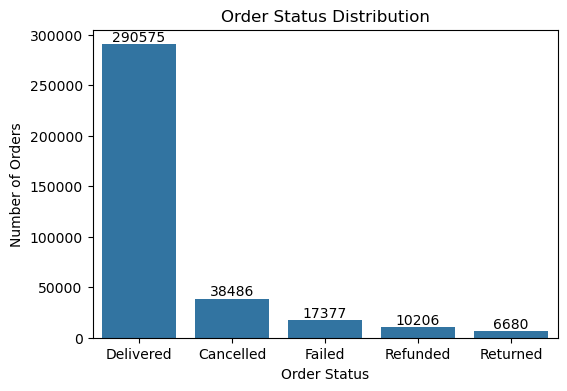

In [53]:
plt.figure(figsize=(6,4))

status = df['Order_Status'].value_counts()

ax = sns.barplot(x=status.index, y=status.values)

ax.bar_label(ax.containers[0])

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

## Customer Gender Distribution

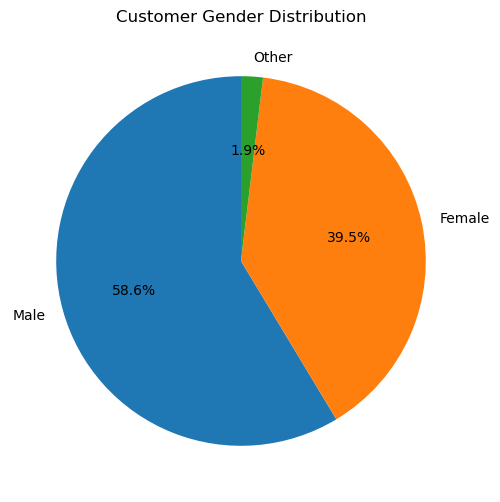

In [54]:
gender = df['Customer_Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(gender.values,
        labels=gender.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Customer Gender Distribution")

plt.show()

## Weather Distribution

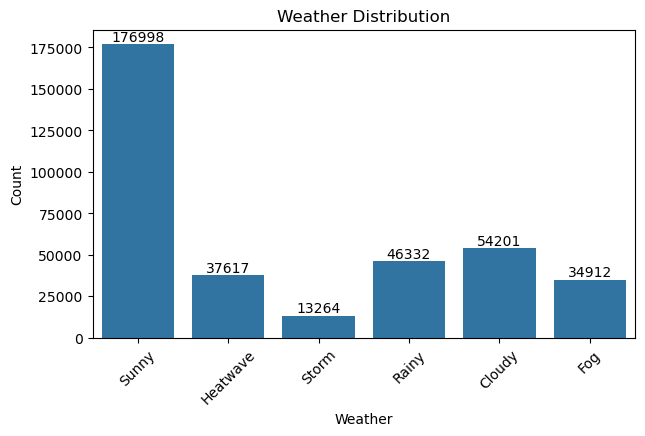

In [55]:
plt.figure(figsize=(7,4))

ax = sns.countplot(data=df, x='Weather')

ax.bar_label(ax.containers[0])

plt.title("Weather Distribution")
plt.xlabel("Weather")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

## Traffic Level Distribution

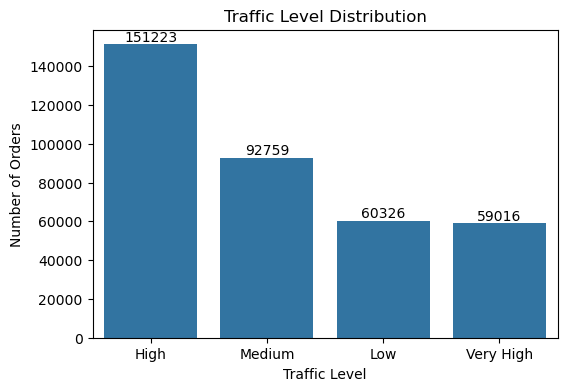

In [56]:
plt.figure(figsize=(6,4))

traffic = df['Traffic_Level'].value_counts()

ax = sns.barplot(x=traffic.index, y=traffic.values)

ax.bar_label(ax.containers[0])

plt.title("Traffic Level Distribution")
plt.xlabel("Traffic Level")
plt.ylabel("Number of Orders")

plt.show()

## Customer Age Distribution

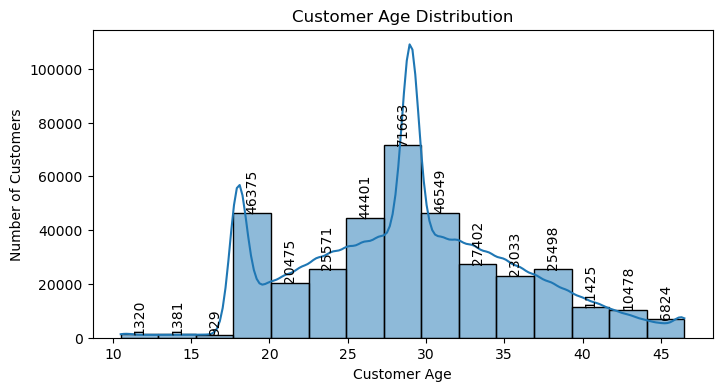

In [69]:
plt.figure(figsize=(8,4))

ax=sns.histplot(df['Customer_Age'], bins=15, kde=True)
ax.bar_label(ax.containers[0],rotation=90)
plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Number of Customers")

plt.show()

## Order Value Distribution

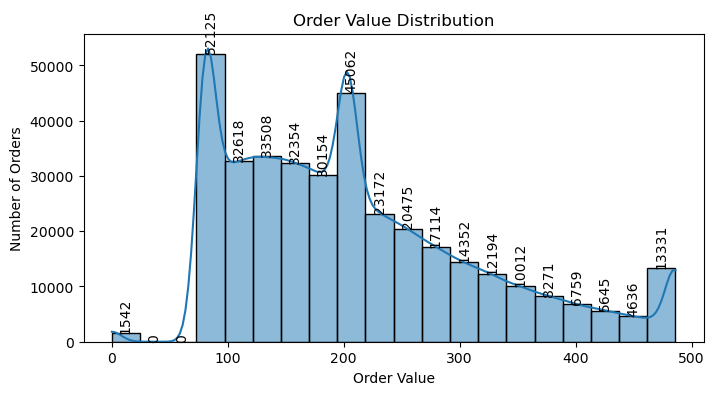

In [68]:
plt.figure(figsize=(8,4))

ax=sns.histplot(df['Order_Value'], bins=20, kde=True)
ax.bar_label(ax.containers[0],rotation=90)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Number of Orders")

plt.show()

## Distance Distribution

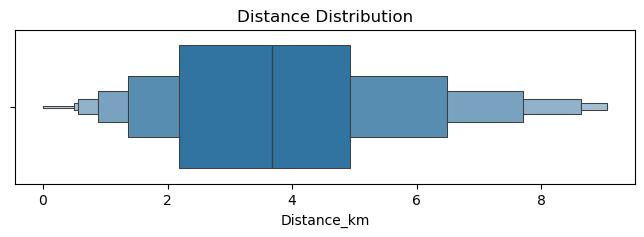

In [71]:
plt.figure(figsize=(8,2))

sns.boxenplot(x=df['Distance_km'])

plt.title("Distance Distribution")

plt.show()

## Delivery Fee Distribution

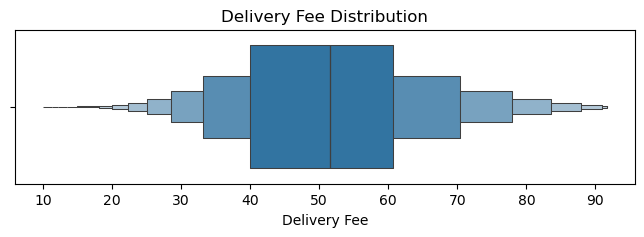

In [60]:
plt.figure(figsize=(8,2))

sns.boxenplot(x=df['Delivery_Fee'])

plt.title("Delivery Fee Distribution")
plt.xlabel("Delivery Fee")

plt.show()

## Discount Distribution

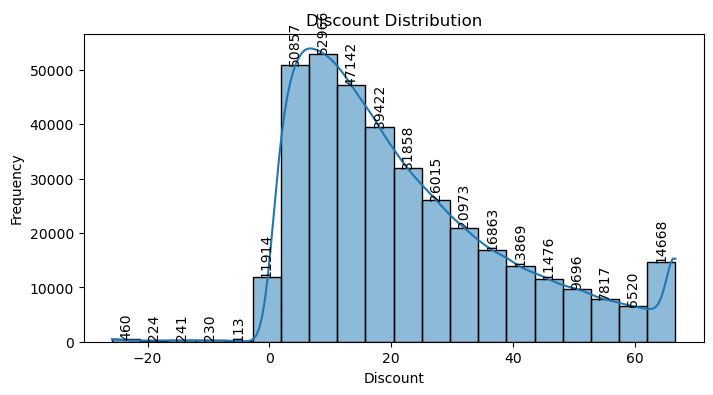

In [72]:
plt.figure(figsize=(8,4))

ax=sns.histplot(df['Discount'], bins=20, kde=True)
ax.bar_label(ax.containers[0],rotation=90)
plt.title("Discount Distribution")
plt.xlabel("Discount")
plt.ylabel("Frequency")

plt.show()

## Average Discount by Payment Method

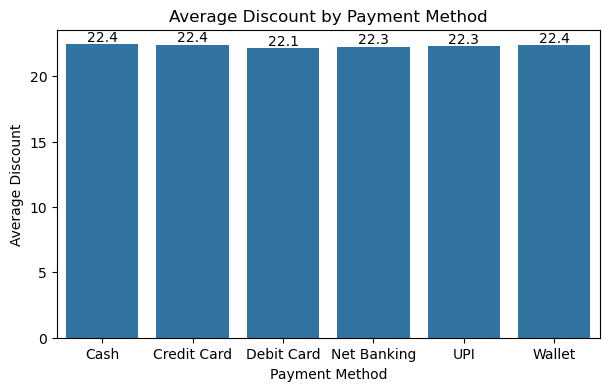

In [62]:
discount = (
    df.groupby('Payment_Method')['Discount']
      .mean()
      .reset_index()
)

plt.figure(figsize=(7,4))

ax = sns.barplot(
    data=discount,
    x='Payment_Method',
    y='Discount'
)

ax.bar_label(ax.containers[0], fmt='%.1f')

plt.title("Average Discount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Discount")

plt.show()

In [103]:
df.columns

Index(['Order_ID', 'Customer_ID', 'Restaurant_ID', 'Delivery_Partner_ID',
       'Order_Date', 'Order_Time', 'City', 'Area', 'Restaurant_Name',
       'Restaurant_Category', 'Customer_Age', 'Customer_Gender', 'Distance_km',
       'Weather', 'Traffic_Level', 'Delivery_Time_Minutes', 'Order_Value',
       'Discount', 'Payment_Method', 'Delivery_Fee', 'Customer_Rating',
       'Order_Status', 'Year', 'Month'],
      dtype='object')

In [104]:
df.head()

,Order_ID,Customer_ID,Restaurant_ID,Delivery_Partner_ID,Order_Date,Order_Time,City,Area,Restaurant_Name,Restaurant_Category,...,Traffic_Level,Delivery_Time_Minutes,Order_Value,Discount,Payment_Method,Delivery_Fee,Customer_Rating,Order_Status,Year,Month
0,ORD0309353,CUST118495,NaN,DP02115,2023-11-05,21:03:05,Mumbai,NaN,Fresh House,Street Food,...,Medium,67.0,231.35,5.20,UPI,NaN,NaN,Delivered,2023,November
1,ORD0124468,CUST021794,REST05389,DP02174,2023-10-09,21:01,Nagpur,Sadar,Annapurna Spot,Juices,...,NaN,29.0,116.82,14.35,UPI,34.76,4.0,Delivered,2023,October
2,ORD0012315,CUST097889,REST06138,DP00225,2023-11-27,20:59:56,Hyderabad,NaN,Little Diner,Juices,...,Medium,40.0,80.00,1.86,Credit Card,26.24,3.0,Returned,2023,November
3,ORD0684514,CUST036679,REST03010,DP00510,2024-10-05,06:07 PM,Bengaluru,BTM Layout,Sizzling Adda,North Indian,...,Medium,22.0,511.85,29.07,UPI,42.03,5.0,Delivered,2024,October
4,ORD0127193,CUST017422,REST04334,DP03177,2023-07-20,12:15:17,Kolkata,NaN,Fresh Tadka,Street Food,...,NaN,58.0,142.33,199.83,Debit Card,64.95,3.0,Delivered,2023,July


In [110]:
month_order_total=pd.pivot_table(df,values='Order_Value',index='Month',aggfunc='sum')
month_order_total

,Order_Value
Month,
April,7771544.08
August,8580742.18
December,8285124.02
February,7543154.90
January,8624733.70
July,8231703.82
June,7961876.03
March,8413975.83
May,8044327.39


<Figure size 1000x2000 with 0 Axes>

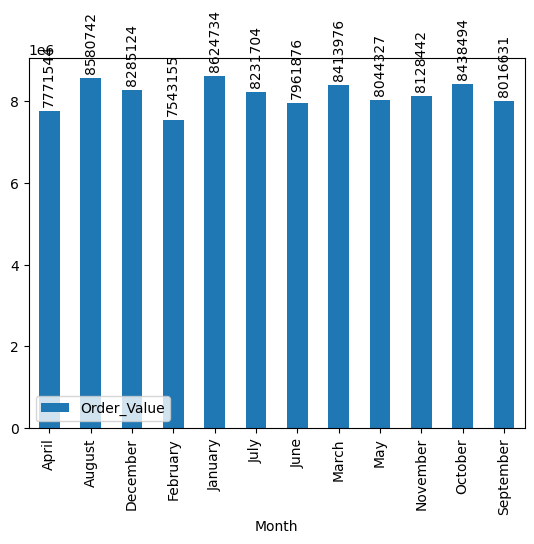

In [128]:
plt.figure(figsize=(10,20))
ax = month_order_total.plot(kind='bar')

for label in ax.containers:
    ax.bar_label(label,fmt='%.0f', rotation=90, padding=3)

plt.show()

## Pivot Table Analysis

In [63]:
##  Average Order Value by City
pivot_city = pd.pivot_table(
    df,
    values='Order_Value',
    index='City',
    aggfunc='mean'
)

pivot_city

,Order_Value
City,
Ahmedabad,207.812519
Bengaluru,210.288137
Chennai,209.514960
Delhi,209.587950
Hyderabad,209.111576
Indore,206.346324
Jaipur,208.494906
Kolkata,207.381160
Lucknow,210.586547


In [64]:
## Average Delivery Fee by Weather
pivot_weather = pd.pivot_table(
    df,
    values='Delivery_Fee',
    index='Weather', 
    aggfunc='mean'
)

pivot_weather


,Delivery_Fee
Weather,
Cloudy,47.730645
Fog,52.539504
Heatwave,47.517728
Rainy,59.463113
Storm,67.010700
Sunny,49.410481


In [65]:
## Average Order Value by City and Payment Method
pivot_payment = pd.pivot_table(
    df,
    values='Order_Value',
    index='City',
    columns='Payment_Method',
    aggfunc='mean'
)

pivot_payment

Payment_Method,Cash,Credit Card,Debit Card,Net Banking,UPI,Wallet
City,,,,,,
Ahmedabad,209.168691,207.316114,208.606751,207.399255,207.380553,208.804267
Bengaluru,212.938429,209.356431,208.397970,209.474991,210.156171,211.283454
Chennai,210.699929,211.326033,209.407067,214.469399,209.082361,206.479079
Delhi,210.034907,206.437188,209.018879,213.610261,209.873736,210.332903
Hyderabad,207.355847,211.916799,209.541007,209.158768,208.661926,210.192641
Indore,206.174216,204.582243,206.100789,197.238716,206.390727,212.135947
Jaipur,211.126411,206.398233,205.687626,209.402906,208.799808,208.715259
Kolkata,209.047818,206.967498,205.682236,207.268186,207.570050,206.335495
Lucknow,208.609275,208.145151,209.983528,205.290103,211.854736,210.383309


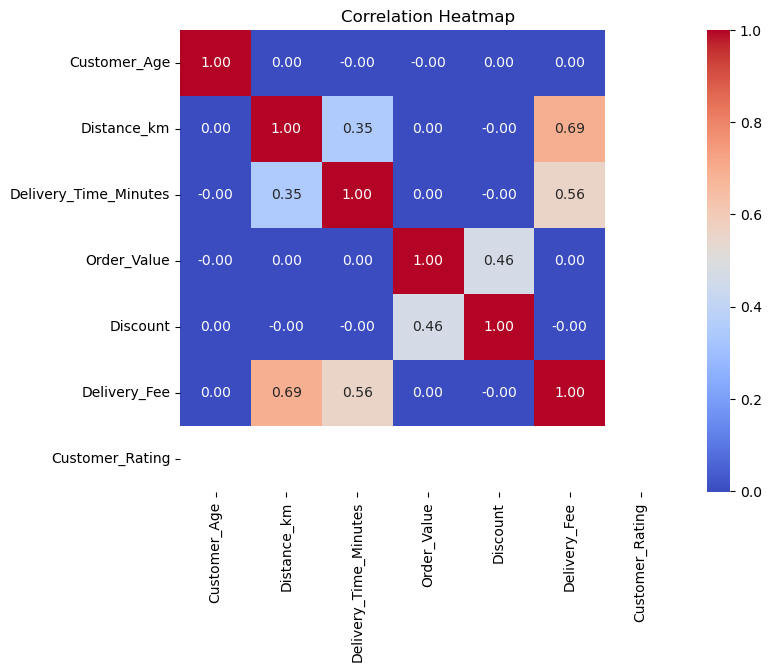

In [66]:
# Select only numerical columns and calculate correlation
correlation = df.corr(numeric_only=True)

# Create the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')

# Add title
plt.title('Correlation Heatmap')

# Display the plot
plt.show()

# Conclusion

- Successfully performed **EDA and data analysis** on the food delivery dataset using Python.
- Cleaned the data by handling **duplicates, inconsistent values, missing values, skewness, and outliers**.
- Analyzed **cities, restaurants, payment methods, customers, weather, and traffic**.
- **Mumbai** had the highest average order value, while **Nagpur** had the lowest.
- **Stormy weather** had the highest average delivery fee.
- Overall, the analysis identified useful **customer, order, payment, and operational patterns**.
- These insights can help improve **pricing, discounts, customer experience, and delivery operations**.